In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Week 1: Orientation and Setup

Note on keys: The following fields are considered `InKeyIndex` fields and may be queried in batches up to 300,000 at a time: `ListingId` , `ListingKey` , `ModificationTimestamp` , `PhotosChangeTimestamp` , `PhotosCount` , `PostalCode` , `StandardStatus`.

| Key name | Key type | Description |
|---|---|---|
|`ListingId`| String | Well-known identifier for listing. Intended for human use for retrieving listings. |
|`ListingKey`| String | Unique identifier of listing from immediate source. |
| `ModificationTimestamp` | DateTimeOffset | System generated timestamp of last modification |
| `PhotosChangeTimestamp` | DateTimeOffset | System generated timestamp of update/change to photos |
| `PhotosCount` | Int32 | Total number of pictures included with listing |
| `PostalCode` | String | Postal code |
| `StandardStatus` | StandardStatus Enum | Current status of listing |

In [2]:
dp = Path('../../data/')
csv_names = []
for item in dp.iterdir():
    if item.is_file():
        #print(item.name)
        csv_names.append(item.name)

df = pd.DataFrame()
for name in csv_names:
    path = Path("../../data/" + name)
    df2 = pd.read_csv(path, low_memory=False)
    #print(len(df2))
    df = pd.concat([df, df2], join='outer', ignore_index=True)
    #print(len(df))
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']

In [4]:
df.to_csv('../../data/New/df_messy.csv', index=False)

In [96]:
price_cols = ['OriginalListPrice', 'ClosePrice', 'ListPrice']
df[price_cols].describe()

,OriginalListPrice,ClosePrice,ListPrice
count,3.983780e+05,3.991550e+05,3.991570e+05
mean,1.336880e+06,1.285092e+06,1.248959e+06
std,6.990745e+06,5.237207e+06,1.559621e+06
min,0.000000e+00,0.000000e+00,4.500000e+02
25%,6.250000e+05,6.200000e+05,6.190000e+05
50%,8.950000e+05,8.890000e+05,8.800000e+05
75%,1.400000e+06,1.425000e+06,1.399000e+06
max,1.390000e+09,9.895000e+08,2.450000e+08


## Week 2: Data Exploration

### Univariate distributions

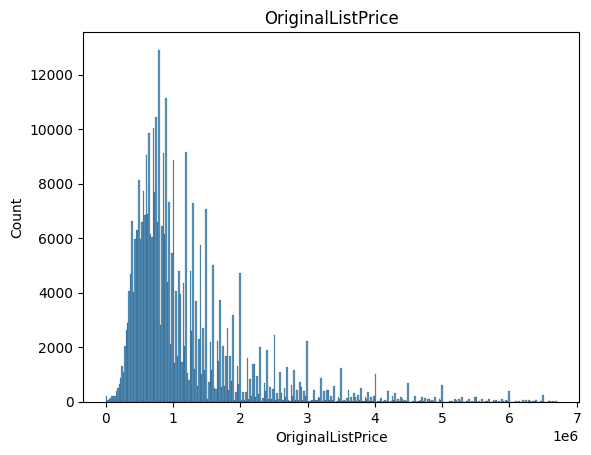

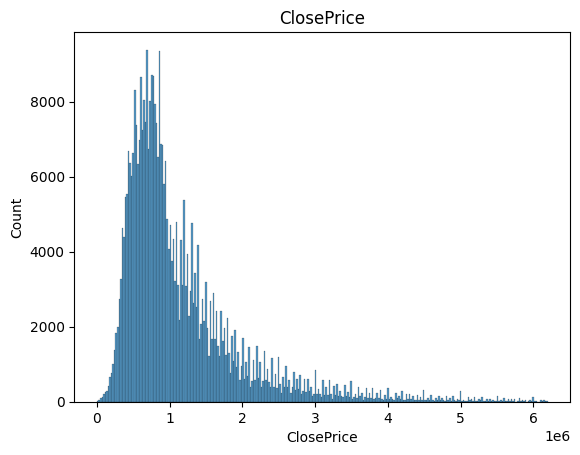

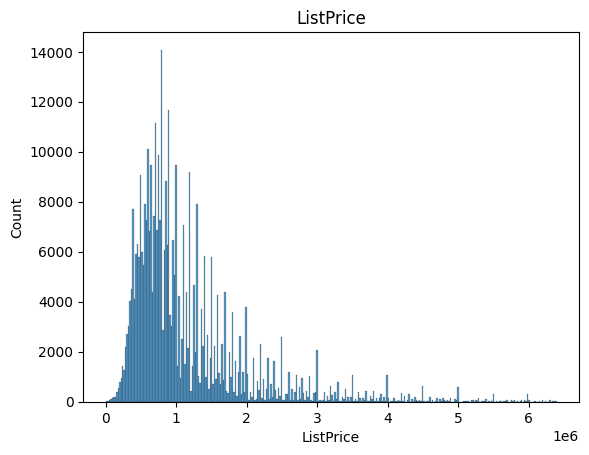

In [97]:
for c in price_cols:
    plt.figure()
    sns.histplot(df[df[c] < df[c].quantile(0.99)][c])
    plt.title(c)
    plt.show()

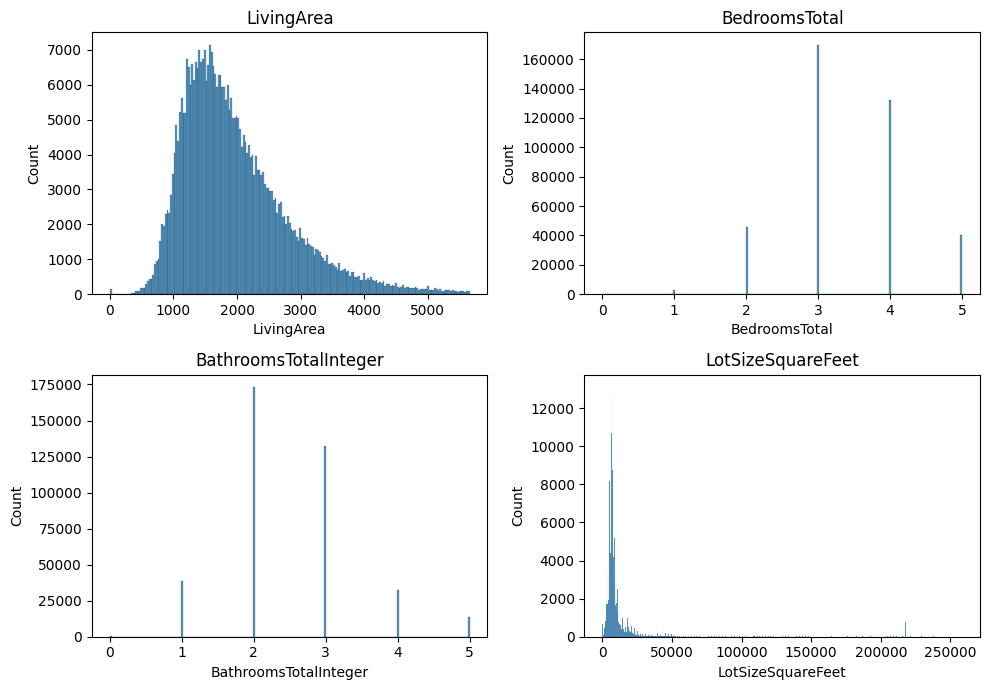

In [98]:
other_cols = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
fig, axes = plt.subplots(2, 2, figsize=(10,7))
for i,c in enumerate(other_cols):
    sns.histplot(df[df[c] < df[c].quantile(0.99)][c], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(c)
plt.tight_layout()
plt.show()

### Scatterplots

#### Scatterplot Matrix

In [99]:
df_numeric = df.select_dtypes(include='float64')

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Define boundaries and drop rows with outliers in ANY column
df_numeric_clean = df_numeric[~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]


df_numeric_clean = df_numeric_clean.drop(columns=['OriginalListPrice', 'Latitude', 'Longitude', 'ListPrice', 'FireplacesTotal', 'AboveGradeFinishedArea',
                                                 'ListingKeyNumeric', 'TaxAnnualAmount', 'ParkingTotal', 'StreetNumberNumeric', 'TaxYear', 'ElementarySchoolDistrict', 
                                                  'BelowGradeFinishedArea', 'CoveredSpaces', 'Stories', 'MainLevelBedrooms', 'GarageSpaces', 'MiddleOrJuniorSchoolDistrict', 
                                                  'AssociationFee', 'BuyerAgencyCompensation', 'LotSizeArea', 'LotSizeAcres'])

cat_cols = ['BathroomsTotalInteger', 'BedroomsTotal']
diff = df_numeric_clean.columns.difference(cat_cols)
df_log = df_numeric_clean.copy()
df_log[diff] = df_numeric_clean[diff].apply(np.log)

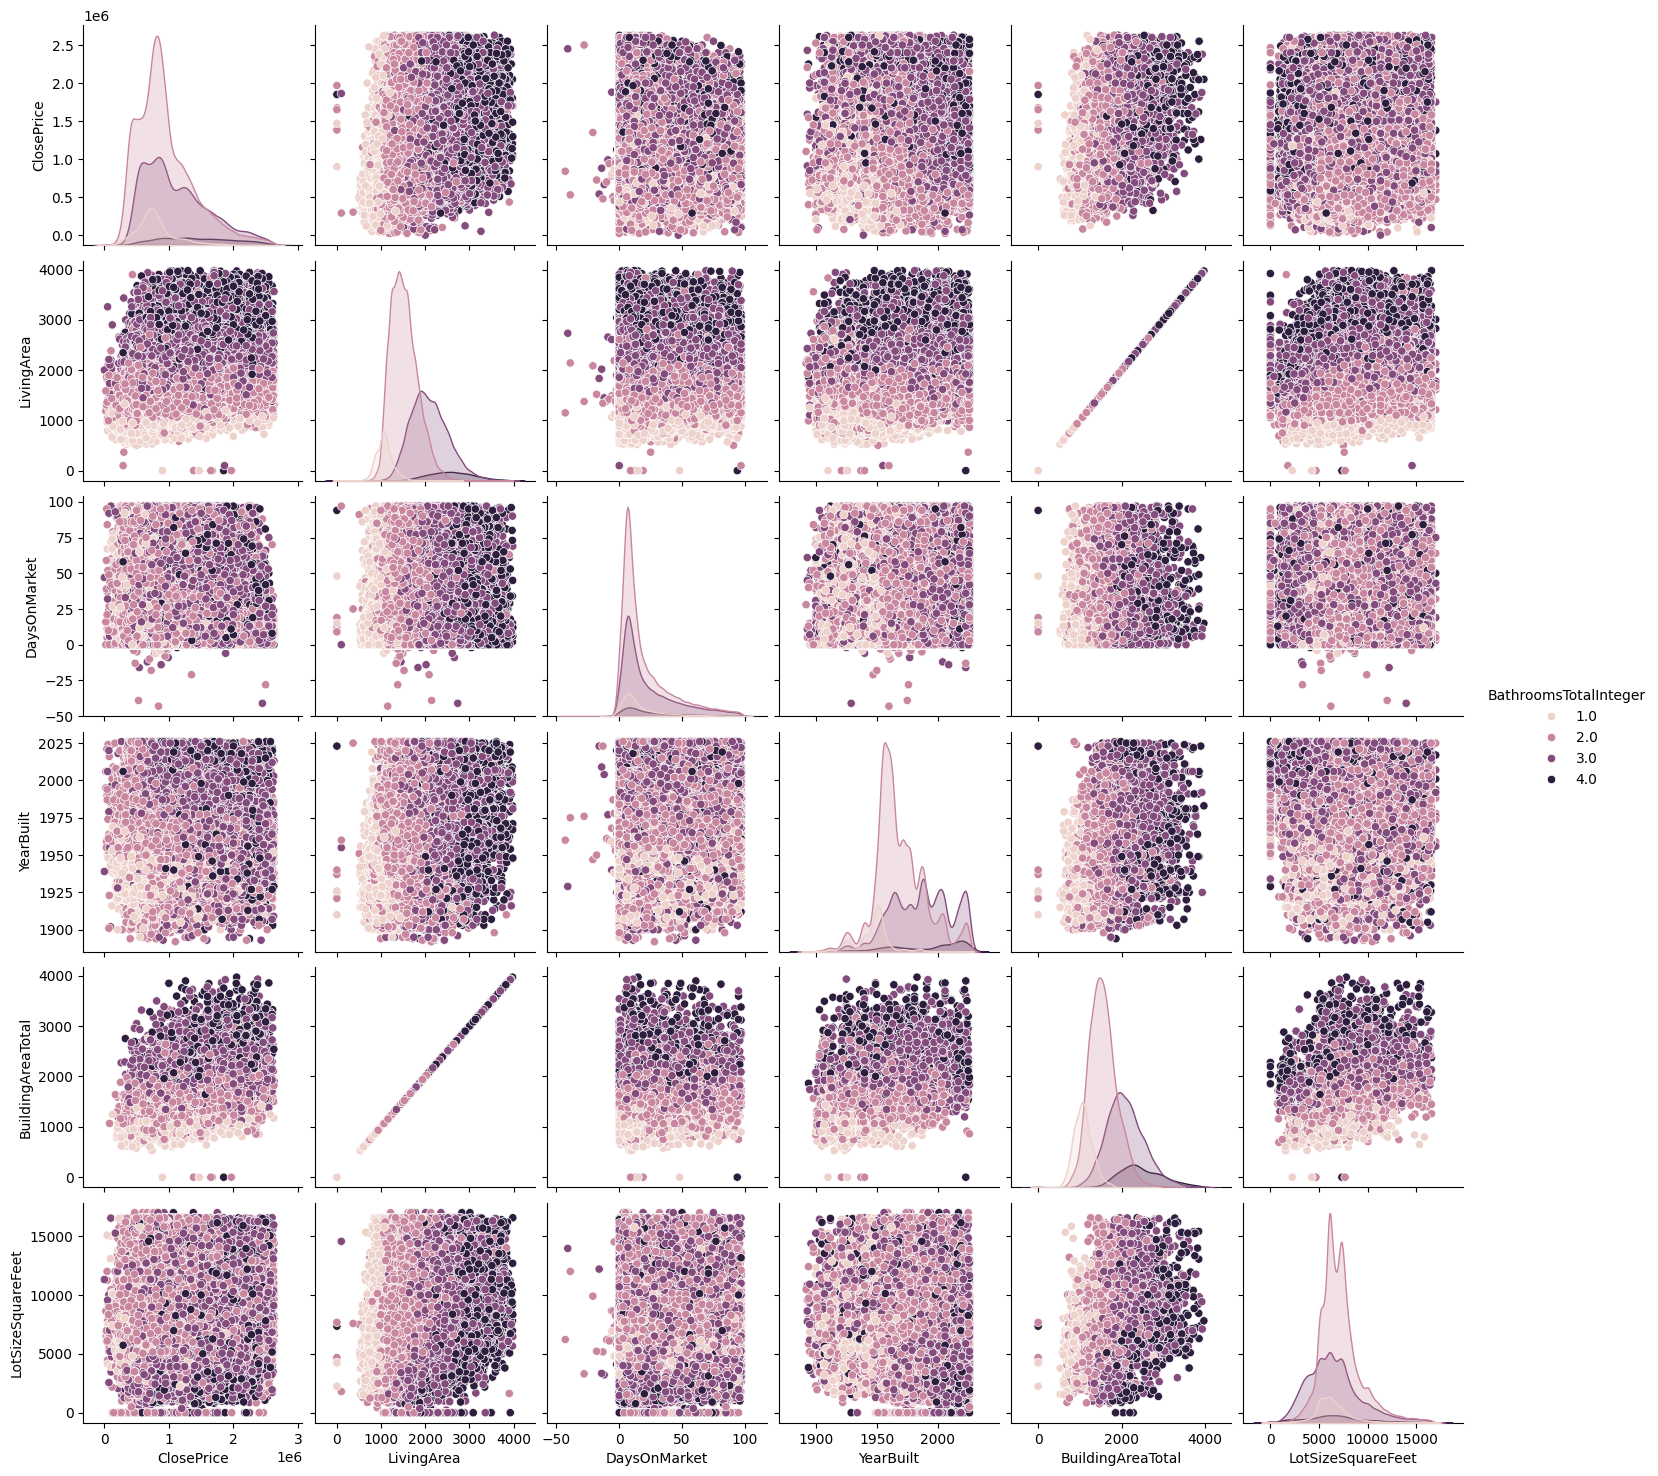

In [100]:
sns.pairplot(df_numeric_clean.drop(columns='BedroomsTotal'), hue='BathroomsTotalInteger')

In [103]:
def plot_corr(df,x,y,hue=False):
    plt.figure()
    if hue:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, s=10)
    else:
        sns.scatterplot(data=df, x=x, y=y, s=10)
    plt.title(f"{y} vs. {x}")
    plt.show()

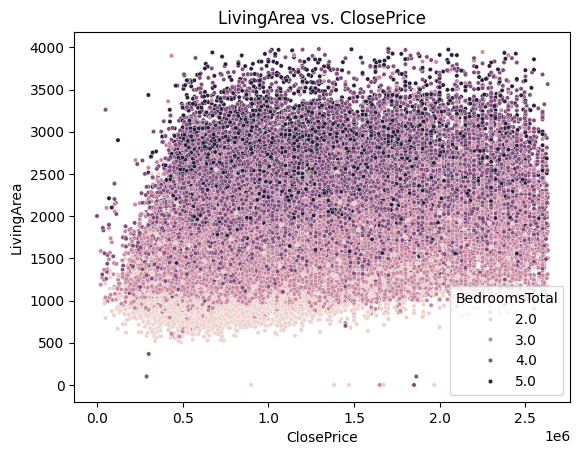

In [104]:
plot_corr(df_numeric_clean, "ClosePrice", "LivingArea", "BedroomsTotal")

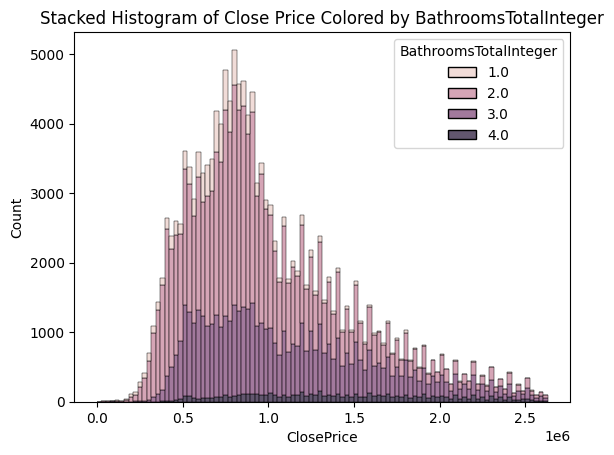

In [105]:
plt.figure()
sns.histplot(data=df_numeric_clean, x="ClosePrice", hue= "BathroomsTotalInteger", multiple="stack", bins=100)
plt.title("Stacked Histogram of Close Price Colored by BathroomsTotalInteger")
plt.show()

In [176]:
df.groupby('StateOrProvince').size()

StateOrProvince
AL         2
AZ         8
BC         1
CA    399130
CO         2
FL         1
GA         1
ME         1
MO         1
NV         3
NY         1
OS         3
TN         1
TX         1
dtype: int64

There are so few listings in states other than California that it makes sense remove those rows entirely

In [248]:
df = df[df['StateOrProvince'] == 'CA']

In [249]:
# Change listing in 'SAN DIEGO' county to 'San Diego'
df.loc[df['CountyOrParish'] == 'SAN DIEGO', 'CountyOrParish'] = 'San Diego'

county_pct = df['CountyOrParish'].value_counts(normalize=True)*100

major_counties = county_pct[county_pct >= 0.05].index
df2 = df['CountyOrParish'].where(df['CountyOrParish'].isin(major_counties), 'Other')

pie_data = df2.value_counts()
print(pie_data)

CountyOrParish
Los Angeles        96425
Riverside          59186
San Bernardino     42821
San Diego          42808
Orange             37323
Alameda            19247
Contra Costa       18764
Santa Clara        17175
Ventura            12308
San Mateo           7437
San Luis Obispo     6384
Monterey            4510
Butte               4489
Kern                4366
Merced              3216
Santa Cruz          3156
Santa Barbara       2218
San Joaquin         2163
Lake                1818
Fresno              1716
Solano              1713
Madera              1612
Other               1595
San Benito          1045
Sacramento          1043
San Francisco        796
Stanislaus           779
Mendocino            484
Glenn                463
Tehama               417
Tulare               411
Mariposa             399
Imperial             325
Kings                273
Placer               245
Name: count, dtype: int64


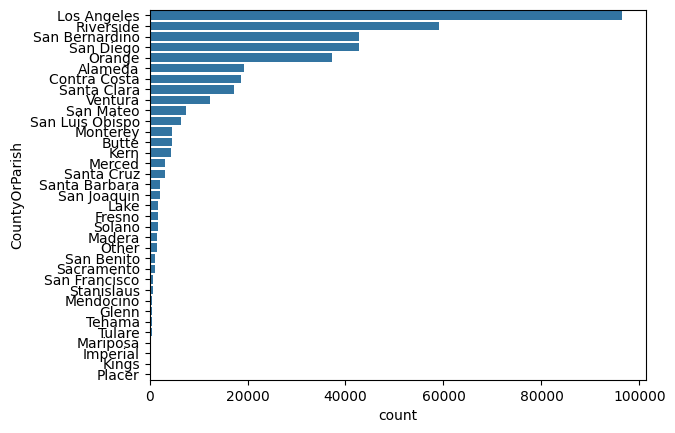

In [250]:
plt.figure()
sns.barplot(pie_data, orient="h")
plt.show()

In [106]:
df_numeric_clean.groupby('BathroomsTotalInteger').mean()

,ClosePrice,LivingArea,DaysOnMarket,YearBuilt,BuildingAreaTotal,BedroomsTotal,LotSizeSquareFeet
BathroomsTotalInteger,,,,,,,
1.0,8.045860e+05,1074.256824,18.211206,1946.874707,1079.620364,2.534663,6456.551736
2.0,9.369188e+05,1515.621881,19.847363,1968.528964,1548.306687,3.211835,7145.050127
3.0,1.120323e+06,2090.509660,23.340316,1986.097415,2090.238291,3.731759,6526.538540
4.0,1.430831e+06,2589.957474,26.057458,1990.150747,2475.840802,4.096088,6772.806921
